In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [38]:
# load csv into df
filename = "time_hist_px_ms.csv"
df = pd.read_csv(filename)
df

,Tiempo (ms),Trayectoria 5,Trayectoria 6
0,0,0.000000,0.000000
1,33,0.014847,0.082718
2,67,0.000694,0.169586
3,100,-0.032425,0.261398
4,133,-0.046612,0.352112
...,...,...,...
486,16185,18.514557,19.548599
487,16218,18.574608,19.481842
488,16252,18.590134,19.355301
489,16285,18.487572,19.181732


In [39]:
df_ref = pd.read_csv(filename.split('.')[0] + '_ref' + '.' + filename.split('.')[1])
df_ref

,Tiempo (ms),Trayectoria 7,Trayectoria 8
0,0,0.000000,0.000000
1,33,0.367466,0.054352
2,67,0.597759,0.111725
3,100,0.672440,0.173904
4,133,0.675747,0.241226
...,...,...,...
486,16185,10.930779,11.553909
487,16218,10.930904,11.758636
488,16252,10.840305,12.036285
489,16285,10.619812,12.291046


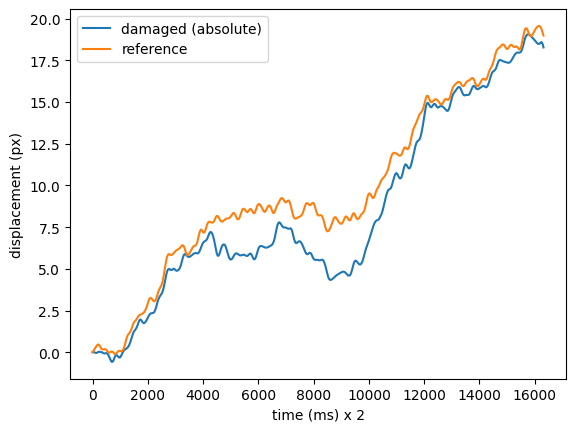

In [40]:
plt.plot(df['Tiempo (ms)'], df['Trayectoria 5'], label='damaged (absolute)')
plt.plot(df['Tiempo (ms)'], df['Trayectoria 6'], label='reference')
plt.xlabel("time (ms) x 2")
plt.ylabel("displacement (px)")
plt.legend()
plt.show()

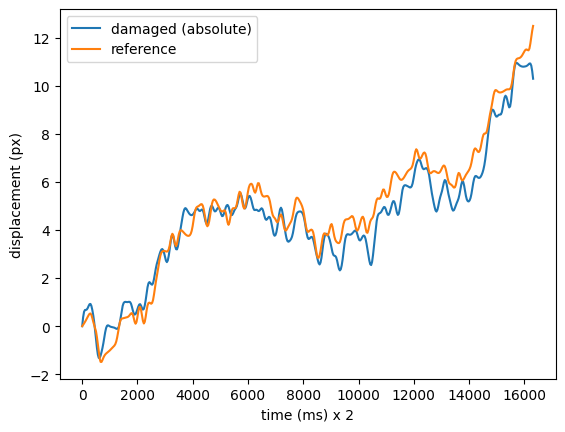

In [41]:
plt.plot(df['Tiempo (ms)'], df_ref['Trayectoria 7'], label='damaged (absolute)')
plt.plot(df['Tiempo (ms)'], df_ref['Trayectoria 8'], label='reference')
plt.xlabel("time (ms) x 2")
plt.ylabel("displacement (px)")
plt.legend()
plt.show()

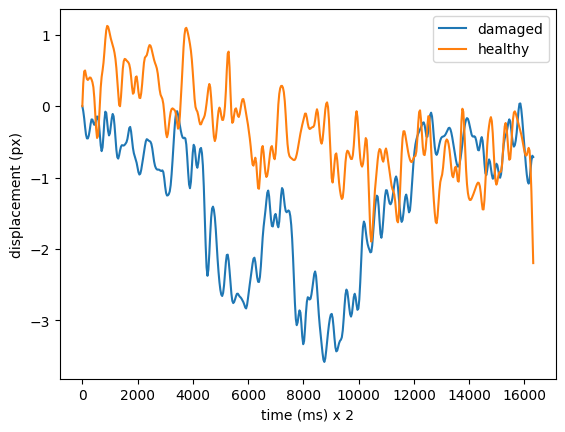

In [42]:
plt.plot(df['Tiempo (ms)'], df['Trayectoria 5'] - df['Trayectoria 6'], label='damaged')
plt.plot(df_ref['Tiempo (ms)'], df_ref['Trayectoria 7'] - df_ref['Trayectoria 8'], label='healthy')
plt.xlabel("time (ms) x 2")
plt.ylabel("displacement (px)")
plt.legend()
plt.show()

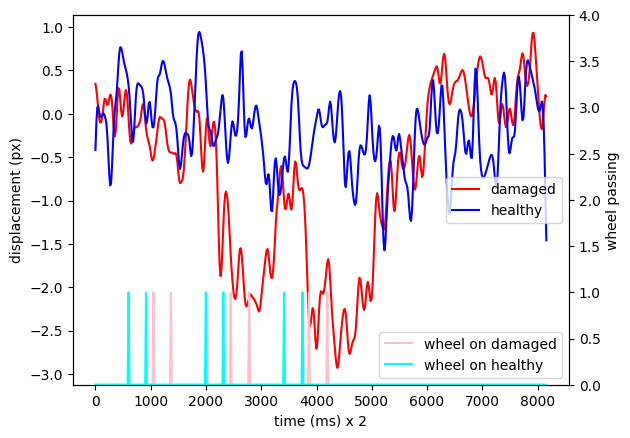

In [64]:
# Process
df_proc = pd.DataFrame(columns=["time_ms", "disp_damaged_px", "disp_healthy_px"])
df_proc['time_ms'] = df['Tiempo (ms)'] / 2.0 # 60 fps / 30 fps
df_proc['disp_damaged_px'] = df['Trayectoria 5'] - df['Trayectoria 6']
df_proc['disp_healthy_px'] = df_ref['Trayectoria 7'] - df_ref['Trayectoria 8']


wheels_damaged_times_ms = 1000*np.array([2.10, 2.74, 4.91, 5.56, 7.74, 8.40]) / 2.0 # 60 fps / 30 fps
wheels_healthy_times_ms = 1000*np.array([1.20, 1.84, 3.99, 4.64, 6.83, 7.49]) / 2.0 # 60 fps / 30 fps

df_proc['wheels_damaged'] = 0*df_proc['time_ms']
for time in wheels_damaged_times_ms:
    idx = np.argmin(np.abs(time - df_proc['time_ms']))
    df_proc['wheels_damaged'].iloc[idx] = 1.0

df_proc['wheels_healthy'] = 0*df_proc['time_ms']
for time in wheels_healthy_times_ms:
    idx = np.argmin(np.abs(time - df_proc['time_ms']))
    df_proc['wheels_healthy'].iloc[idx] = 1.0


def drift_removal(s: pd.Series):
    pad = 2
    window = 10
    s_ini = np.mean(s.values[pad:window])
    s_fin = np.mean(s.values[-window:-pad])
    delta_y = s_fin - s_ini
    delta_x = len(s)
    s_drift_removed = s - (delta_y/delta_x)*np.linspace(0, delta_x, delta_x) - s_ini

    return s_drift_removed

df_proc['disp_damaged_px_drift_removed'] = drift_removal(df_proc['disp_damaged_px'])
df_proc['disp_healthy_px_drift_removed'] = drift_removal(df_proc['disp_healthy_px'])

# plt.plot(df_proc['time_ms'], df_proc['disp_damaged_px'])
plt.plot(df_proc['time_ms'], df_proc['disp_damaged_px_drift_removed'], label='damaged', color='red')
plt.plot(df_proc['time_ms'], df_proc['disp_healthy_px_drift_removed'], label='healthy', color='blue')
plt.xlabel("time (ms) x 2")
plt.ylabel("displacement (px)")
plt.legend(loc='right')
ax_twin = plt.gca().twinx()

ax_twin.plot(df_proc['time_ms'], df_proc['wheels_damaged'], label='wheel on damaged', linestyle='-', color='pink')
ax_twin.plot(df_proc['time_ms'], df_proc['wheels_healthy'], label='wheel on healthy', linestyle='-', color='cyan')
ax_twin.set_ylim(0,4)
ax_twin.set_ylabel("wheel passing")
ax_twin.legend(loc='lower right')

plt.show()

In [59]:
df_proc['disp_damaged_px']

0      0.000000
1     -0.067871
2     -0.168892
3     -0.293823
4     -0.398724
         ...   
486   -1.034042
487   -0.907234
488   -0.765167
489   -0.694160
490   -0.712097
Name: disp_damaged_px, Length: 491, dtype: float64

In [60]:
df_proc['disp_healthy_px']

0      0.000000
1      0.313114
2      0.486034
3      0.498535
4      0.434521
         ...   
486   -0.623131
487   -0.827732
488   -1.195980
489   -1.671234
490   -2.197651
Name: disp_healthy_px, Length: 491, dtype: float64